### Identity Check
* Convert target image into embedding
* Compare with stored embeddings using cosine similarity

In [54]:
# Quick import test
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import faiss
    _FAISS_OK = True
except Exception:
    _FAISS_OK = False

try:
    import sklearn
    from sklearn.metrics import roc_curve, auc, roc_auc_score
    _SKLEARN_OK = True
except Exception:
    _SKLEARN_OK = False

print("faiss:", _FAISS_OK, "sklearn:", _SKLEARN_OK)

faiss: True sklearn: True


In [55]:
# Baseline identity evaluation (pooled templates)
OUT_DIR = Path("../data_processed/vggface2")
PROBE_DIR = OUT_DIR / "embeddings" / "probe"
TEMPLATES_PATH = OUT_DIR / "templates_enroll.npy"
TEMPLATES_MAP = OUT_DIR / "templates_map_enroll.csv"
INDEX_PATH = OUT_DIR / "templates_enroll.index"

# Config
K_TOP = 5
IMP_K = 100
FAR_LEVELS = [1e-2, 1e-3]

# Load templates and probes
templates = np.load(TEMPLATES_PATH).astype("float32")
tmap = pd.read_csv(TEMPLATES_MAP)
if "template_index" in tmap.columns:
    tmap = tmap.sort_values("template_index").reset_index(drop=True)
person_ids = tmap["person_id"].astype(str).tolist()
n_templates = templates.shape[0]
print(f"Templates loaded: {n_templates}")

templates = templates / np.linalg.norm(templates, axis=1, keepdims=True).clip(min=1e-12)

probe_emb = np.load(PROBE_DIR / "embeddings.npy").astype("float32")
probe_map = pd.read_csv(PROBE_DIR / "embeddings_map.csv")
probe_emb = probe_emb / np.linalg.norm(probe_emb, axis=1, keepdims=True).clip(min=1e-12)
N = probe_emb.shape[0]
print(f"Probes loaded: {N}")

# Load/build faiss
if _FAISS_OK:
    try:
        base_index = faiss.read_index(str(INDEX_PATH))
        print("Loaded FAISS index from:", INDEX_PATH)
    except Exception:
        dim = templates.shape[1]
        base_index = faiss.IndexFlatIP(dim)
        base_index.add(templates)
        print("Built FAISS index from templates (no file found).")
else:
    base_index = None
    print("faiss not available; using numpy fallback (slower).")

# Search Top-K
k = min(max(1, K_TOP), n_templates)
t0 = time.time()
if base_index is not None:
    D, I = base_index.search(probe_emb, k)
    topk_scores = D
    topk_idx = I
else:
    # fallback chunked
    batch = 4096
    topk_scores = np.empty((N, k), dtype="float32")
    topk_idx = np.empty((N, k), dtype="int64")
    for i in range(0, N, batch):
        block = probe_emb[i:i+batch] @ templates.T
        idxs = np.argpartition(-block, kth=k-1, axis=1)[:, :k]
        row_k_scores = np.take_along_axis(block, idxs, axis=1)
        order = np.argsort(-row_k_scores, axis=1)
        idxs_sorted = np.take_along_axis(idxs, order, axis=1)
        scores_sorted = np.take_along_axis(block, idxs_sorted, axis=1)
        topk_scores[i:i+batch] = scores_sorted
        topk_idx[i:i+batch] = idxs_sorted
t_elapsed = time.time() - t0
print(f"Search done. method: {'faiss' if base_index is not None else 'dot'}, time: {t_elapsed:.2f}s")

pred_persons_topk = [[person_ids[j] for j in row] for row in topk_idx]
true_persons = probe_map["person_id"].astype(str).tolist()
top1 = np.mean([pred_persons_topk[i][0] == true_persons[i] for i in range(N)])
topk = np.mean([true_persons[i] in pred_persons_topk[i] for i in range(N)])
print(f"Top-1: {top1:.4f}   Top-{k}: {topk:.4f}")

# Prepare per-probe genuine & impostor metrics (used downstream)
# person -> template list
person_to_tidx = {}
for idx, pid in enumerate(person_ids):
    person_to_tidx.setdefault(pid, []).append(idx)

# genuine max per-probe
genuine_scores = np.full(N, np.nan, dtype="float32")
for i in range(N):
    pid = true_persons[i]
    if pid in person_to_tidx:
        idxs = person_to_tidx[pid]
        genuine_scores[i] = float(np.max(probe_emb[i].dot(templates[idxs].T)))

# impostor neighbors sampling (per-probe max impostor + pool)
imp_k = min(IMP_K, n_templates)
impostor_scores_all = []
max_impostor_per_probe = np.full(N, np.nan, dtype="float32")
if base_index is not None:
    D_imp, I_imp = base_index.search(probe_emb, imp_k)
    for i in range(N):
        pid = true_persons[i]
        scores_i = []
        for score, tidx in zip(D_imp[i], I_imp[i]):
            if person_ids[tidx] == pid:
                continue
            scores_i.append(float(score))
        if scores_i:
            impostor_scores_all.extend(scores_i)
            max_impostor_per_probe[i] = float(max(scores_i))
else:
    for i in range(N):
        block = probe_emb[i].dot(templates.T)
        pid = true_persons[i]
        if pid in person_to_tidx:
            for gidx in person_to_tidx[pid]:
                block[gidx] = -np.inf
        topk_vals = np.sort(block)[-imp_k:]
        impostor_scores_all.extend(topk_vals.tolist())
        if len(topk_vals) > 0:
            max_impostor_per_probe[i] = float(topk_vals[-1])

impostor_scores_all = np.array(impostor_scores_all, dtype="float32")
print("Collected impostor samples:", impostor_scores_all.shape[0])

Templates loaded: 540
Probes loaded: 39758
Loaded FAISS index from: ..\data_processed\vggface2\templates_enroll.index
Search done. method: faiss, time: 0.07s
Top-1: 0.9316   Top-5: 0.9776
Collected impostor samples: 3936098


In [56]:
# HQ per-pose template identity evaluation
import numpy as np, pandas as pd
from pathlib import Path
import time

# Paths for HQ templates produced by enrollment.ipynb
EMB_ENROLL_DIR = Path("../data_processed/vggface2/embeddings/enroll")
HQ_TPLS_PATH = EMB_ENROLL_DIR / "templates_pose_hq.npy"
HQ_MAP_PATH  = EMB_ENROLL_DIR / "templates_map_pose_hq.csv"
HQ_INDEX_PATH = EMB_ENROLL_DIR / "templates_pose_hq.index"

PROBE_DIR = Path("../data_processed/vggface2/embeddings/probe")
PROBE_EMB = PROBE_DIR / "embeddings.npy"
PROBE_MAP = PROBE_DIR / "embeddings_map.csv"

if not (HQ_TPLS_PATH.exists() and HQ_MAP_PATH.exists()):
    print("HQ templates not found at:", HQ_TPLS_PATH, "or map:", HQ_MAP_PATH)
else:
    tpls = np.load(HQ_TPLS_PATH).astype("float32")
    tmap = pd.read_csv(HQ_MAP_PATH)

    # preserve template ordering if template_idx column present
    if "template_idx" in tmap.columns:
        tmap = tmap.sort_values("template_idx").reset_index(drop=True)

    person_ids = tmap["person_id"].astype(str).tolist()
    n_templates = tpls.shape[0]
    print(f"HQ templates loaded: {n_templates} (rows in map: {len(tmap)})")

    # normalize templates
    tpls /= np.linalg.norm(tpls, axis=1, keepdims=True).clip(min=1e-12)

    # load probes
    probe_emb = np.load(PROBE_EMB).astype("float32")
    probe_map = pd.read_csv(PROBE_MAP)
    N = probe_emb.shape[0]
    print(f"Probes loaded: {N}")

    # normalize probes
    probe_emb /= np.linalg.norm(probe_emb, axis=1, keepdims=True).clip(min=1e-12)

    # try loading FAISS index if available, else build
    try:
        import faiss
        try:
            index = faiss.read_index(str(HQ_INDEX_PATH))
            print("Loaded HQ FAISS index:", HQ_INDEX_PATH)
        except Exception:
            dim = tpls.shape[1]
            index = faiss.IndexFlatIP(dim)
            index.add(tpls)
            print("Built FAISS index for HQ templates (no index file found).")
        use_faiss = True
    except Exception:
        index = None
        use_faiss = False
        print("faiss not available; will use numpy dot-product fallback (slower).")

    # search top-1
    k = 1
    t0 = time.time()
    if use_faiss:
        D, I = index.search(probe_emb, k)
        top_idx = I[:,0]
        top_scores = D[:,0]
    else:
        # simple dot-product top-1
        top_idx = np.argmax(probe_emb @ tpls.T, axis=1)
        top_scores = (probe_emb * tpls[top_idx]).sum(axis=1)
    elapsed = time.time() - t0
    print(f"HQ search done. time: {elapsed:.2f}s")

    # map to person ids and compute Top-1 accuracy
    pred_persons = [person_ids[i] for i in top_idx]
    true_persons = probe_map["person_id"].astype(str).tolist()
    top1 = np.mean([p==t for p,t in zip(pred_persons, true_persons)])
    print("HQ Top-1 identification (HQ per-pose + pooled fallback):", f"{top1:.4f}")

    # basic diagnostics: pooled_fallback coverage and per-person counts
    if "type" in tmap.columns:
        n_pooled = (tmap["type"] == "pooled_fallback").sum()
        n_hq = (tmap["type"] == "hq_per_pose").sum()
        print(f"HQ per-pose templates: {n_hq}; pooled_fallback templates: {n_pooled}")


HQ templates loaded: 3218 (rows in map: 3218)
Probes loaded: 39758
Loaded HQ FAISS index: ..\data_processed\vggface2\embeddings\enroll\templates_pose_hq.index
HQ search done. time: 0.43s
HQ Top-1 identification (HQ per-pose + pooled fallback): 0.9317
HQ per-pose templates: 2678; pooled_fallback templates: 540


In [57]:
# HQ per-pose Top-1 evaluation (single-cell quick check)
EMB_ENROLL_DIR = Path("../data_processed/vggface2/embeddings/enroll")
HQ_TPLS_PATH = EMB_ENROLL_DIR / "templates_pose_hq.npy"
HQ_MAP_PATH  = EMB_ENROLL_DIR / "templates_map_pose_hq.csv"
HQ_INDEX_PATH = EMB_ENROLL_DIR / "templates_pose_hq.index"

PROBE_DIR = Path("../data_processed/vggface2/embeddings/probe")
PROBE_EMB = PROBE_DIR / "embeddings.npy"
PROBE_MAP = PROBE_DIR / "embeddings_map.csv"

if not (HQ_TPLS_PATH.exists() and HQ_MAP_PATH.exists()):
    print("HQ templates or map not found:", HQ_TPLS_PATH, HQ_MAP_PATH)
else:
    tpls = np.load(HQ_TPLS_PATH).astype("float32")
    tmap = pd.read_csv(HQ_MAP_PATH)
    if "template_idx" in tmap.columns:
        tmap = tmap.sort_values("template_idx").reset_index(drop=True)
    person_ids_hq = tmap["person_id"].astype(str).tolist()
    tpls = tpls / np.linalg.norm(tpls, axis=1, keepdims=True).clip(min=1e-12)

    probe_emb = np.load(PROBE_EMB).astype("float32")
    probe_map = pd.read_csv(PROBE_MAP)
    probe_emb = probe_emb / np.linalg.norm(probe_emb, axis=1, keepdims=True).clip(min=1e-12)

    # index
    use_faiss = False
    try:
        import faiss
        try:
            hq_index = faiss.read_index(str(HQ_INDEX_PATH))
            print("Loaded HQ FAISS index:", HQ_INDEX_PATH)
        except Exception:
            dim = tpls.shape[1]
            hq_index = faiss.IndexFlatIP(dim)
            hq_index.add(tpls)
            print("Built HQ FAISS index (no file found).")
        use_faiss = True
    except Exception:
        hq_index = None
        print("faiss not available; using numpy fallback.")

    # search top-1
    k = 1
    t0 = time.time()
    if use_faiss:
        D, I = hq_index.search(probe_emb, k)
        top_idx = I[:,0]
        top_scores = D[:,0]
    else:
        top_idx = np.argmax(probe_emb @ tpls.T, axis=1)
        top_scores = (probe_emb * tpls[top_idx]).sum(axis=1)
    elapsed = time.time() - t0
    pred_persons = [person_ids_hq[i] for i in top_idx]
    true_persons = probe_map["person_id"].astype(str).tolist()
    top1 = np.mean([p==t for p,t in zip(pred_persons, true_persons)])
    print("HQ Top-1 identification (HQ per-pose + pooled fallback):", f"{top1:.4f}")
    if "type" in tmap.columns:
        print("HQ per-pose templates:", (tmap["type"]=="hq_per_pose").sum(), "pooled_fallback:", (tmap["type"]=="pooled_fallback").sum())

Loaded HQ FAISS index: ..\data_processed\vggface2\embeddings\enroll\templates_pose_hq.index
HQ Top-1 identification (HQ per-pose + pooled fallback): 0.9317
HQ per-pose templates: 2678 pooled_fallback: 540


In [58]:
# Helpers used by combined evaluation and diagnostics
def l2norm_rows(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    n[n == 0] = 1.0
    return x / n

def compute_thresholds_from_per_probe_max_impostor(max_impostor_per_probe, FAR_LEVELS):
    valid = max_impostor_per_probe[np.isfinite(max_impostor_per_probe)]
    out = {}
    for far in FAR_LEVELS:
        if valid.size == 0:
            out[far] = float("nan")
        else:
            out[far] = float(np.percentile(valid, 100*(1.0 - far)))
    return out

def confusion_at_thresh_per_probe(pred_scores, pred_persons, true_persons, thresh):
    Nloc = len(pred_scores)
    pred_accept = pred_scores >= thresh
    correct = np.array([p==t for p,t in zip(pred_persons, true_persons)])
    TP = int(np.sum(pred_accept & correct))
    FP = int(np.sum(pred_accept & ~correct))
    FN = int(np.sum(~pred_accept & correct))
    TN = int(np.sum(~pred_accept & ~correct))
    return {"TP":TP, "FP":FP, "FN":FN, "TN":TN, "N":Nloc}

Evaluating baseline...
Evaluating HQ...
Wrote comparison CSV: ..\data_processed\vggface2\identity_eval_comparison_thresholds.csv
Wrote summary JSON: ..\data_processed\vggface2\identity_eval_summary.json


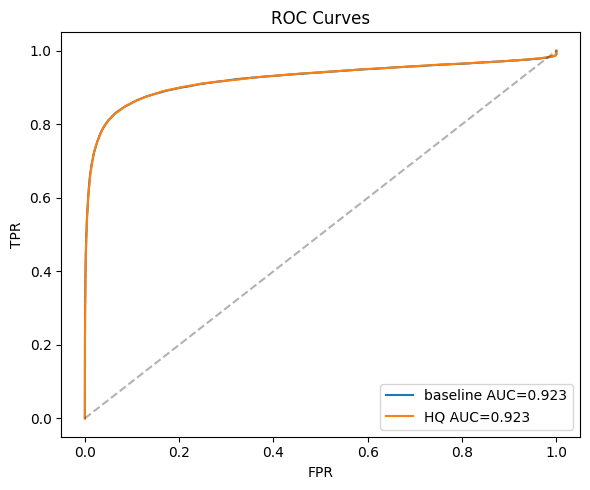

Saved ROC plot: ..\data_processed\vggface2\plots\roc_baseline_vs_hq.png

Baseline Top-1: 0.9316, templates: 540
HQ      Top-1: 0.9317, templates: 3218

FAR=0.01:
  baseline -> thresh: 0.7411, TAR: 0.6478
  hq       -> thresh: 0.7586, TAR: 0.6431

FAR=0.001:
  baseline -> thresh: 0.8174, TAR: 0.3694
  hq       -> thresh: 0.8387, TAR: 0.3263
Saved per-strategy arrays for further analysis.


In [59]:
# Combined evaluation: evaluate baseline and HQ, using per-probe max-impostor for thresholds and ROC
import json, os
OUT_DIR = Path("../data_processed/vggface2")
PROBE_DIR = OUT_DIR / "embeddings" / "probe"
PROBE_EMB = PROBE_DIR / "embeddings.npy"
PROBE_MAP = PROBE_DIR / "embeddings_map.csv"
FAR_LEVELS = [1e-2, 1e-3]
IMP_K = 100
SAVE_PREFIX = OUT_DIR / "identity_eval"
PLOT_DIR = OUT_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True, parents=True)

def evaluate_templates(name, tpl_path, map_path, index_path=None):
    tpls = np.load(tpl_path).astype("float32")
    tmap = pd.read_csv(map_path)
    if "template_idx" in tmap.columns:
        tmap = tmap.sort_values("template_idx").reset_index(drop=True)
    tpls = l2norm_rows(tpls)
    person_ids = tmap["person_id"].astype(str).tolist()
    n_templates = tpls.shape[0]

    probe_emb = np.load(PROBE_EMB).astype("float32")
    probe_map = pd.read_csv(PROBE_MAP)
    probe_emb = l2norm_rows(probe_emb)
    N = probe_emb.shape[0]

    # load/build index
    index = None
    if index_path is not None and _FAISS_OK:
        try:
            index = faiss.read_index(str(index_path))
        except Exception:
            index = None
    if index is None and _FAISS_OK:
        dim = tpls.shape[1]
        index = faiss.IndexFlatIP(dim)
        index.add(tpls)
    # person->template indices
    person_to_tidx = {}
    for idx, pid in enumerate(person_ids):
        person_to_tidx.setdefault(pid, []).append(idx)

    # top-1 per probe
    if index is not None:
        D, I = index.search(probe_emb, 1)
        top_tpl_idx = I[:,0]
        top_scores = D[:,0]
    else:
        scores_all = probe_emb @ tpls.T
        top_tpl_idx = np.argmax(scores_all, axis=1)
        top_scores = scores_all[np.arange(N), top_tpl_idx]
    pred_persons = [person_ids[i] for i in top_tpl_idx]
    true_persons = probe_map["person_id"].astype(str).tolist()
    top1 = float(np.mean([p == t for p,t in zip(pred_persons, true_persons)]))

    # genuine (per-probe max over that person's templates)
    genuine_scores = np.full(N, np.nan, dtype="float32")
    for i in range(N):
        pid = true_persons[i]
        if pid in person_to_tidx:
            idxs = person_to_tidx[pid]
            genuine_scores[i] = float(np.max(probe_emb[i].dot(tpls[idxs].T)))

    # impostor: per-probe max impostor and pool sample
    imp_k = min(IMP_K, n_templates)
    impostor_scores_all = []
    max_impostor_per_probe = np.full(N, np.nan, dtype="float32")
    if index is not None:
        D_imp, I_imp = index.search(probe_emb, imp_k)
        for i in range(N):
            pid = true_persons[i]
            scores_i = []
            for score, tidx in zip(D_imp[i], I_imp[i]):
                if person_ids[tidx] == pid:
                    continue
                scores_i.append(float(score))
            if scores_i:
                impostor_scores_all.extend(scores_i)
                max_impostor_per_probe[i] = float(max(scores_i))
    else:
        for i in range(N):
            block = probe_emb[i].dot(tpls.T)
            pid = true_persons[i]
            if pid in person_to_tidx:
                for gidx in person_to_tidx[pid]:
                    block[gidx] = -np.inf
            topk_vals = np.sort(block)[-imp_k:]
            impostor_scores_all.extend(topk_vals.tolist())
            if len(topk_vals)>0:
                max_impostor_per_probe[i] = float(topk_vals[-1])
    impostor_scores_all = np.array(impostor_scores_all, dtype="float32")

    # ROC/AUC/EER using per-probe genuine vs per-probe max-impostor
    roc_data = None
    valid_genuine = genuine_scores[np.isfinite(genuine_scores)]
    valid_max_impostor = max_impostor_per_probe[np.isfinite(max_impostor_per_probe)]
    if _SKLEARN_OK and valid_genuine.size>0 and valid_max_impostor.size>0:
        y_true = np.concatenate([np.ones(valid_genuine.size), np.zeros(valid_max_impostor.size)])
        y_score = np.concatenate([valid_genuine, valid_max_impostor])
        fpr, tpr, thr = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        fnr = 1 - tpr
        idx_eer = np.nanargmin(np.abs(fnr - fpr))
        eer = float((fpr[idx_eer] + fnr[idx_eer]) / 2.0)
        roc_data = {"fpr": fpr.tolist(), "tpr": tpr.tolist(), "thresholds": thr.tolist(), "auc": float(roc_auc), "eer": eer}
    else:
        roc_data = None

    # thresholds at FAR levels computed from per-probe max-impostor distribution
    thresholds = {}
    tar_at_far = {}
    for far in FAR_LEVELS:
        if valid_max_impostor.size == 0:
            thresholds[far] = float("nan")
            tar_at_far[far] = float("nan")
        else:
            thr = float(np.percentile(valid_max_impostor, 100*(1.0 - far)))
            thresholds[far] = thr
            tar_at_far[far] = float(np.mean(valid_genuine >= thr)) if valid_genuine.size>0 else float("nan")

    # confusions using per-probe decision (top_scores >= thr)
    confs = {}
    for far in FAR_LEVELS:
        thr = thresholds[far]
        confs[far] = confusion_at_thresh_per_probe(top_scores, pred_persons, true_persons, thr)

    out = {
        "name": name,
        "n_templates": int(n_templates),
        "top1": top1,
        "thresholds": thresholds,
        "tar_at_far": tar_at_far,
        "confs": confs,
        "roc": roc_data,
        "_arrays": {
            "genuine_scores": genuine_scores,
            "max_impostor_per_probe": max_impostor_per_probe,
            "impostor_scores_all": impostor_scores_all,
            "top_scores": top_scores,
            "pred_persons": pred_persons,
            "true_persons": true_persons
        }
    }
    return out

# Evaluate both strategies
baseline = {
    "name": "baseline_pooled",
    "tpl_path": OUT_DIR / "templates_enroll.npy",
    "map_path": OUT_DIR / "templates_map_enroll.csv",
    "index_path": OUT_DIR / "templates_enroll.index"
}
hq = {
    "name": "hq_pose",
    "tpl_path": OUT_DIR / "embeddings/enroll/templates_pose_hq.npy",
    "map_path": OUT_DIR / "embeddings/enroll/templates_map_pose_hq.csv",
    "index_path": OUT_DIR / "embeddings/enroll/templates_pose_hq.index"
}

print("Evaluating baseline...")
res_base = evaluate_templates(**baseline)
print("Evaluating HQ...")
res_hq = evaluate_templates(**hq)

# Save comparison CSV and JSON and ROC plot
rows = []
for res in (res_base, res_hq):
    for far in FAR_LEVELS:
        thr = res["thresholds"].get(far, float("nan"))
        tar = res["tar_at_far"].get(far, float("nan"))
        conf = res["confs"].get(far, {})
        rows.append({
            "strategy": res["name"],
            "n_templates": res["n_templates"],
            "top1": res["top1"],
            "far": far,
            "threshold": thr,
            "TAR": tar,
            "TP": conf.get("TP"),
            "FP": conf.get("FP"),
            "FN": conf.get("FN"),
            "TN": conf.get("TN"),
            "N": conf.get("N")
        })
df_comp = pd.DataFrame(rows)
csv_out = SAVE_PREFIX.with_name(SAVE_PREFIX.name + "_comparison_thresholds.csv")
df_comp.to_csv(csv_out, index=False)
print("Wrote comparison CSV:", csv_out)

summary = {
    "baseline": {k:v for k,v in res_base.items() if k!="_arrays"},
    "hq": {k:v for k,v in res_hq.items() if k!="_arrays"}
}
json_out = SAVE_PREFIX.with_name(SAVE_PREFIX.name + "_summary.json")
with open(json_out, "w") as f:
    json.dump(summary, f, indent=2)
print("Wrote summary JSON:", json_out)

# Plot ROC curves
plt.figure(figsize=(6,5))
if res_base["roc"] is not None:
    plt.plot(res_base["roc"]["fpr"], res_base["roc"]["tpr"], label=f"baseline AUC={res_base['roc']['auc']:.3f}")
if res_hq["roc"] is not None:
    plt.plot(res_hq["roc"]["fpr"], res_hq["roc"]["tpr"], label=f"HQ AUC={res_hq['roc']['auc']:.3f}")
plt.plot([0,1],[0,1], "k--", alpha=0.3)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curves")
plt.legend()
roc_png = PLOT_DIR / "roc_baseline_vs_hq.png"
plt.tight_layout()
plt.savefig(roc_png, dpi=150)
plt.show()
print("Saved ROC plot:", roc_png)

# Print concise comparison summary
print(f"\nBaseline Top-1: {res_base['top1']:.4f}, templates: {res_base['n_templates']}")
print(f"HQ      Top-1: {res_hq['top1']:.4f}, templates: {res_hq['n_templates']}")
for far in FAR_LEVELS:
    print(f"\nFAR={far}:")
    print("  baseline -> thresh: {:.4f}, TAR: {:.4f}".format(res_base["thresholds"].get(far, np.nan), res_base["tar_at_far"].get(far, np.nan)))
    print("  hq       -> thresh: {:.4f}, TAR: {:.4f}".format(res_hq["thresholds"].get(far, np.nan), res_hq["tar_at_far"].get(far, np.nan)))

# Save per-strategy arrays for deeper analyses
np.save(SAVE_PREFIX.with_name(SAVE_PREFIX.name + "_baseline_arrays.npy"), res_base["_arrays"], allow_pickle=True)
np.save(SAVE_PREFIX.with_name(SAVE_PREFIX.name + "_hq_arrays.npy"), res_hq["_arrays"], allow_pickle=True)
print("Saved per-strategy arrays for further analysis.")

In [60]:
# Compare HQ+fallback with baseline pooled templates
BASE_TPLS_PATH = "../data_processed/vggface2/templates_enroll.npy"
BASE_MAP_PATH = "../data_processed/vggface2/templates_map_enroll.csv"
BASE_INDEX_PATH = "../data_processed/vggface2/templates_enroll.index"

base_tpls = np.load(BASE_TPLS_PATH).astype("float32")
base_map = pd.read_csv(BASE_MAP_PATH)
base_tpls /= np.linalg.norm(base_tpls, axis=1, keepdims=True).clip(min=1e-12)

# Load probes (already normalized)
probe_emb = np.load(PROBE_EMB).astype("float32")
probe_map = pd.read_csv(PROBE_MAP)

# Build or load FAISS index
try:
    base_index = faiss.read_index(BASE_INDEX_PATH)
except Exception:
    base_index = faiss.IndexFlatIP(base_tpls.shape[1])
    base_index.add(base_tpls)

# Search Top-1
D, I = base_index.search(probe_emb, 1)
pred_persons = [base_map.iloc[idx]["person_id"] for idx in I[:, 0]]
true_persons = probe_map["person_id"].tolist()
top1_baseline = np.mean([p == t for p, t in zip(pred_persons, true_persons)])
print(f"Baseline Top-1 identification: {top1_baseline:.4f}")

Baseline Top-1 identification: 0.9316


In [61]:
# Per-person diagnostics + TAR@FAR for enroll templates (writes templates_enroll_performance.csv)
import numpy as np
import pandas as pd
from pathlib import Path
import time
import faiss
from collections import defaultdict

OUT_DIR = Path("../data_processed/vggface2")
TEMPLATES_PATH = OUT_DIR / "templates_enroll.npy"
TEMPLATES_MAP  = OUT_DIR / "templates_map_enroll.csv"
INDEX_PATH     = OUT_DIR / "templates_enroll.index"
PROBE_DIR      = OUT_DIR / "embeddings/probe"

IMP_K = 100          # impostor neighbors per probe to sample
FAR_LEVELS = [1e-2, 1e-3]
BACKUP_COLS = ["person_id","n_images","n_used","template_index"]

assert TEMPLATES_PATH.exists() and TEMPLATES_MAP.exists(), "Missing enroll templates or map."
templates = np.load(TEMPLATES_PATH).astype("float32")
tmap = pd.read_csv(TEMPLATES_MAP)
# ensure ordering by template_index if provided
if "template_index" in tmap.columns:
    tmap = tmap.sort_values("template_index").reset_index(drop=True)
person_ids = tmap["person_id"].astype(str).tolist()
n_templates = templates.shape[0]

# load probe embeddings and map
probe_emb = np.load(PROBE_DIR / "embeddings.npy").astype("float32")
probe_map = pd.read_csv(PROBE_DIR / "embeddings_map.csv")
N = probe_emb.shape[0]
print(f"Loaded {n_templates} templates, {N} probes")

# normalize
templates /= np.linalg.norm(templates, axis=1, keepdims=True).clip(min=1e-12)
probe_emb /= np.linalg.norm(probe_emb, axis=1, keepdims=True).clip(min=1e-12)

# build/load faiss (IndexFlatIP for normalized vectors)
try:
    index = faiss.read_index(str(INDEX_PATH))
    print("Loaded FAISS index from", INDEX_PATH)
except Exception:
    dim = templates.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(templates)
    print("Built FAISS index from templates")

# person -> template index (if multiple templates per person, keep first)
person_to_tidx = {}
for idx, pid in enumerate(person_ids):
    person_to_tidx.setdefault(pid, []).append(idx)

# compute genuine score per probe (max over templates for that person if multiple)
genuine_scores = np.full(N, np.nan, dtype="float32")
for i in range(N):
    pid = str(probe_map.iloc[i]["person_id"])
    if pid in person_to_tidx:
        idxs = person_to_tidx[pid]
        # if multiple templates, use max score to represent best-match
        scores = probe_emb[i].dot(templates[idxs].T)
        genuine_scores[i] = float(np.max(scores))

# --- Compute per-probe max-impostor (preferred) ---
imp_k = min(IMP_K, n_templates)
max_impostor_per_probe = np.full(N, np.nan, dtype="float32")

# Use the FAISS neighbors we already computed: D_imp, I_imp are available from above
# If not present, run a neighbor search now
try:
    D_imp, I_imp
except NameError:
    D_imp, I_imp = index.search(probe_emb, imp_k)

for i in range(N):
    pid = str(probe_map.iloc[i]["person_id"])
    scores_i = []
    for score, tidx in zip(D_imp[i], I_imp[i]):
        if person_ids[tidx] == pid:
            continue
        scores_i.append(float(score))
    if scores_i:
        max_impostor_per_probe[i] = float(max(scores_i))

valid_max = max_impostor_per_probe[np.isfinite(max_impostor_per_probe)]
print("Collected per-probe max impostor count:", valid_max.size)

# thresholds per FAR computed from per-probe max-impostor distribution
thresholds = {}
for far in FAR_LEVELS:
    if valid_max.size == 0:
        thresholds[far] = float("nan")
    else:
        thresholds[far] = float(np.percentile(valid_max, 100.0 * (1.0 - far)))
print("Thresholds (from per-probe max-impostor):", thresholds)

# Now compute per-person TAR@FAR using these thresholds
grouped = defaultdict(list)
for i in range(N):
    pid = str(probe_map.iloc[i]["person_id"])
    if not np.isnan(genuine_scores[i]):
        grouped[pid].append(genuine_scores[i])

rows = []
for _, row in tmap.iterrows():
    pid = str(row["person_id"])
    vals = np.array(grouped.get(pid, []), dtype="float32")
    n_probes = len(vals)
    if n_probes > 0:
        mean_score = float(vals.mean())
        median_score = float(np.median(vals))
        tar_at = {f"TAR@FAR_{far}": float((vals >= thresholds[far]).mean()) if not np.isnan(thresholds[far]) else np.nan for far in FAR_LEVELS}
    else:
        mean_score = np.nan
        median_score = np.nan
        tar_at = {f"TAR@FAR_{far}": np.nan for far in FAR_LEVELS}
    rows.append({
        "person_id": pid,
        "n_enroll_images": int(row.get("n_images", 0)) if "n_images" in row else int(row.get("n_used", 0)),
        "n_probe_samples": n_probes,
        "mean_probe_score": mean_score,
        "median_probe_score": median_score,
        **tar_at
    })

perf_df = pd.DataFrame(rows).sort_values(["TAR@FAR_0.01","mean_probe_score"], ascending=[True, True])
out_perf = OUT_DIR / "templates_enroll_performance.csv"
perf_df.to_csv(out_perf, index=False)
print("Wrote per-person performance ->", out_perf)
# show worst-performing persons
print("Worst 10 (by TAR@FAR=0.01):")
print(perf_df.head(10)[["person_id","n_probe_samples","TAR@FAR_0.01","mean_probe_score"]])

Loaded 540 templates, 39758 probes
Loaded FAISS index from ..\data_processed\vggface2\templates_enroll.index
Collected per-probe max impostor count: 39758
Thresholds (from per-probe max-impostor): {0.01: 0.741060733795166, 0.001: 0.817383885383606}
Wrote per-person performance -> ..\data_processed\vggface2\templates_enroll_performance.csv
Worst 10 (by TAR@FAR=0.01):
    person_id  n_probe_samples  TAR@FAR_0.01  mean_probe_score
405   n000410               40      0.000000          0.518849
521   n000998               46      0.021739          0.552331
431   n000436               40      0.050000          0.637820
432   n000437               35      0.057143          0.568620
539   n001296               61      0.065574          0.572058
501   n000654               40      0.075000          0.529017
481   n000486               43      0.093023          0.555981
536   n001277               49      0.122449          0.559477
529   n001174               47      0.127660          0.640000
4

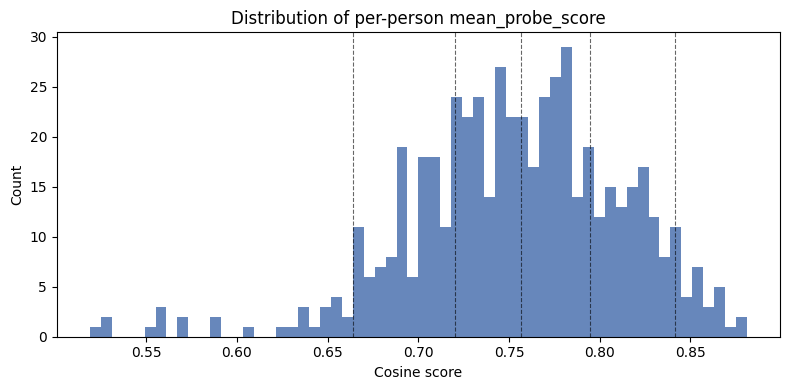

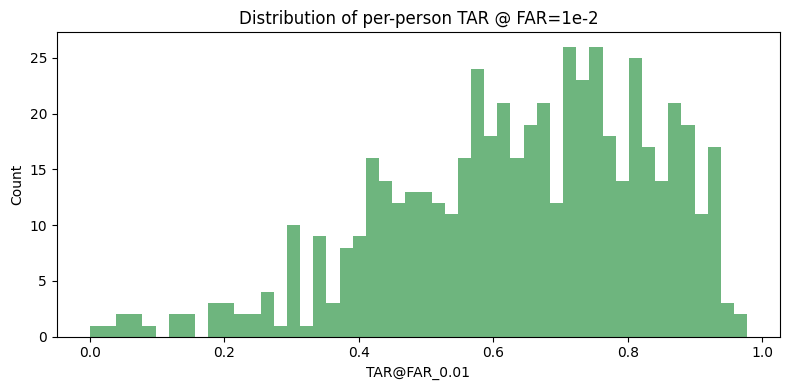

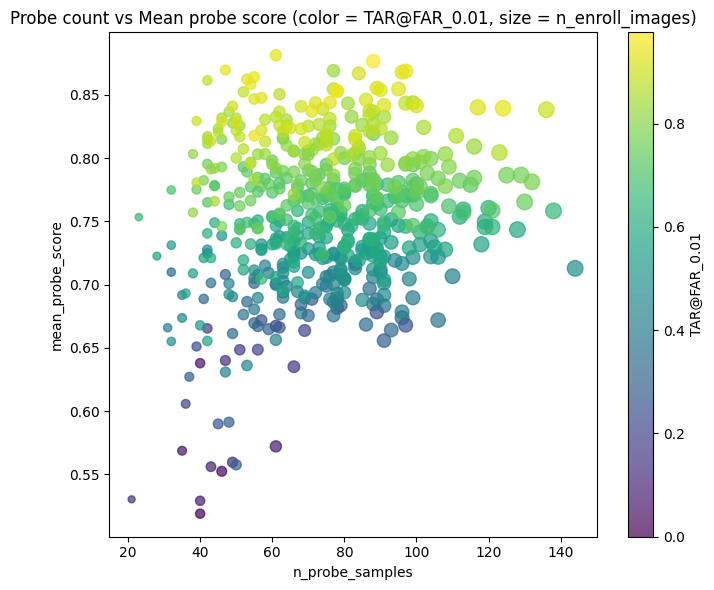

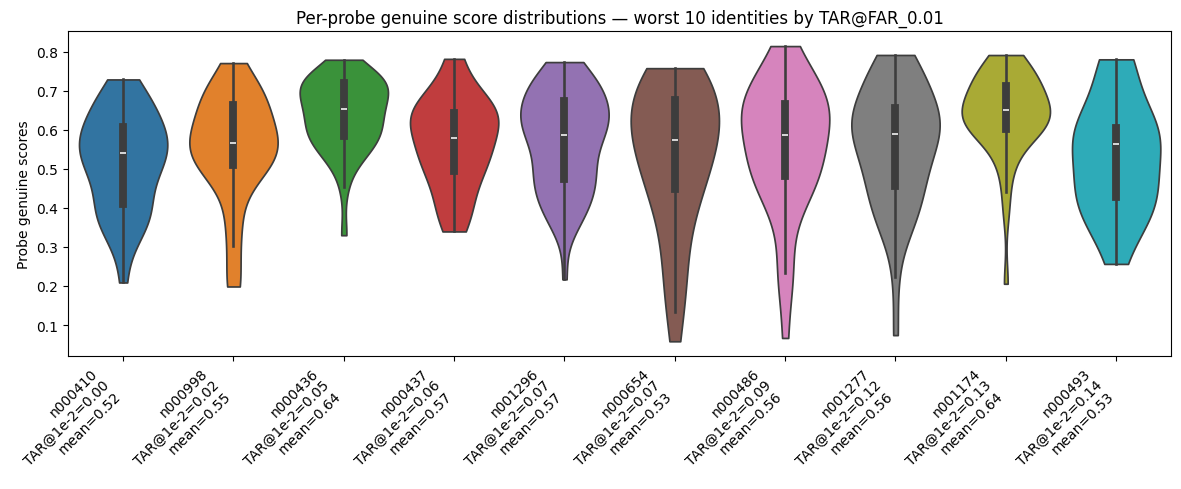

Saved plots to: ..\data_processed\vggface2\plots


In [62]:
# Plots for per-person performance (histograms, scatter, per-person violins/boxplots)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

OUT_DIR = Path("../data_processed/vggface2")
PERF_CSV = OUT_DIR / "templates_enroll_performance.csv"
TEMPLATES_PATH = OUT_DIR / "templates_enroll.npy"
TEMPLATES_MAP  = OUT_DIR / "templates_map_enroll.csv"
PROBE_DIR = OUT_DIR / "embeddings/probe"
PLOT_DIR = OUT_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True, parents=True)

# Config
WORST_K = 10        # how many worst identities to show as violins/boxplots
RANDOM_SEED = 12345

# Load summary CSV (if present) for quick plots
if not PERF_CSV.exists():
    raise FileNotFoundError(f"Missing performance CSV: {PERF_CSV}")
perf_df = pd.read_csv(PERF_CSV)

# Basic histograms from perf_df
plt.figure(figsize=(8,4))
plt.hist(perf_df["mean_probe_score"].dropna(), bins=60, color="#4C72B0", alpha=0.85)
q = np.percentile(perf_df["mean_probe_score"].dropna(), [5,25,50,75,95])
for v in q:
    plt.axvline(v, color="k", linestyle="--", alpha=0.6, linewidth=0.8)
plt.title("Distribution of per-person mean_probe_score")
plt.xlabel("Cosine score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(PLOT_DIR / "mean_probe_score_hist.png", dpi=150)
plt.show()

plt.figure(figsize=(8,4))
plt.hist(perf_df["TAR@FAR_0.01"].dropna(), bins=50, color="#55A868", alpha=0.85)
plt.title("Distribution of per-person TAR @ FAR=1e-2")
plt.xlabel("TAR@FAR_0.01")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(PLOT_DIR / "tar_far1e-2_hist.png", dpi=150)
plt.show()

# Scatter: n_probe_samples vs mean_probe_score (size ~ n_enroll_images)
plt.figure(figsize=(7,6))
# Ensure numeric and clamp enroll counts
enroll_counts = pd.to_numeric(perf_df["n_enroll_images"].fillna(0), errors="coerce").clip(0, 500)
max_enroll = max(1, int(enroll_counts.max()))   # avoid zero-division
sizes = (enroll_counts / max_enroll) * 120
plt.scatter(perf_df["n_probe_samples"].fillna(0), perf_df["mean_probe_score"].fillna(0),
            s=sizes + 6, alpha=0.7, c=perf_df["TAR@FAR_0.01"].fillna(0), cmap="viridis")
cbar = plt.colorbar()
cbar.set_label("TAR@FAR_0.01")
plt.xlabel("n_probe_samples")
plt.ylabel("mean_probe_score")
plt.title("Probe count vs Mean probe score (color = TAR@FAR_0.01, size = n_enroll_images)")
plt.tight_layout()
plt.savefig(PLOT_DIR / "nprobe_vs_meanscore_scatter.png", dpi=150)
plt.show()

# Recompute per-probe genuine scores so we can plot per-person distributions
if not (TEMPLATES_PATH.exists() and TEMPLATES_MAP.exists()):
    print("Templates or map missing; skipping per-person violin/boxplot step.")
else:
    templates = np.load(TEMPLATES_PATH).astype("float32")
    tmap = pd.read_csv(TEMPLATES_MAP)
    if "template_index" in tmap.columns:
        tmap = tmap.sort_values("template_index").reset_index(drop=True)
    person_ids = tmap["person_id"].astype(str).tolist()

    # build person->template indices (support multiple templates per person)
    person_to_tidx = {}
    for idx, pid in enumerate(person_ids):
        person_to_tidx.setdefault(pid, []).append(idx)

    # load probes and compute genuine (best per-person template) score per probe
    probe_emb_path = PROBE_DIR / "embeddings.npy"
    probe_map_path = PROBE_DIR / "embeddings_map.csv"
    if not probe_emb_path.exists() or not probe_map_path.exists():
        print("Probe embeddings or map not found; skipping per-person distribution plots.")
    else:
        probe_emb = np.load(probe_emb_path).astype("float32")
        probe_map = pd.read_csv(probe_map_path)
        # normalize
        templates /= np.linalg.norm(templates, axis=1, keepdims=True).clip(min=1e-12)
        probe_emb /= np.linalg.norm(probe_emb, axis=1, keepdims=True).clip(min=1e-12)

        grouped = defaultdict(list)
        N = probe_emb.shape[0]
        for i in range(N):
            pid = str(probe_map.iloc[i]["person_id"])
            if pid in person_to_tidx:
                idxs = person_to_tidx[pid]
                # compute scores against the person's templates and take max
                scores = probe_emb[i].dot(templates[idxs].T)
                grouped[pid].append(float(np.max(scores)))
        # pick worst K by TAR@FAR_0.01 (already sorted in perf_df)
        worst = perf_df.sort_values("TAR@FAR_0.01", ascending=True).head(WORST_K)["person_id"].astype(str).tolist()
        # collect lists (use NaN list if missing)
        data_for_plot = [grouped.get(pid, []) for pid in worst]
        # Prepare labels showing TAR and mean for annotation
        labels = []
        for pid in worst:
            r = perf_df[perf_df["person_id"].astype(str) == pid]
            if len(r):
                labels.append(f"{pid}\nTAR@1e-2={r.iloc[0]['TAR@FAR_0.01']:.2f}\nmean={r.iloc[0]['mean_probe_score']:.2f}")
            else:
                labels.append(pid)

        # Try seaborn violin, fallback to matplotlib boxplot if seaborn not present
        try:
            import seaborn as sns
            plt.figure(figsize=(max(10, WORST_K*1.2), 5))
            sns.violinplot(data=data_for_plot, inner="box", cut=0)
            plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha="right")
            plt.ylabel("Probe genuine scores")
            plt.title(f"Per-probe genuine score distributions — worst {WORST_K} identities by TAR@FAR_0.01")
            plt.tight_layout()
            plt.savefig(PLOT_DIR / f"worst_{WORST_K}_violins.png", dpi=150)
            plt.show()
        except Exception:
            # matplotlib boxplot fallback
            plt.figure(figsize=(max(10, WORST_K*1.2), 5))
            plt.boxplot([arr if len(arr)>0 else [np.nan] for arr in data_for_plot], showfliers=False)
            plt.xticks(ticks=np.arange(1, len(labels)+1), labels=labels, rotation=45, ha="right")
            plt.ylabel("Probe genuine scores")
            plt.title(f"Per-probe genuine score boxplots — worst {WORST_K} identities by TAR@FAR_0.01")
            plt.tight_layout()
            plt.savefig(PLOT_DIR / f"worst_{WORST_K}_boxplots.png", dpi=150)
            plt.show()

print(f"Saved plots to: {PLOT_DIR}")

In [64]:
# compute confusion / TAR@FAR for existing variables (robust, per-probe max-impostor)
# Replaces the older compute_threshold_from_impostors/confusion_at_thresh usage.
# Requires: either `max_impostor_per_probe` OR `impostor_scores_all` to exist,
# and a decision score array: prefer `top_scores`, then `scores_top1`, then `topk_scores[:,0]`.
import numpy as np
import pandas as pd

# choose FARs
FARs = FAR_LEVELS if 'FAR_LEVELS' in globals() else [1e-2, 1e-3]

# find per-probe max-impostor distribution if available
if 'max_impostor_per_probe' in globals() and np.isfinite(max_impostor_per_probe).any():
    per_probe_impostor = max_impostor_per_probe[np.isfinite(max_impostor_per_probe)]
    source = "max_impostor_per_probe"
elif 'impostor_scores_all' in globals() and np.asarray(impostor_scores_all).size > 0:
    # fallback: compute per-probe maxima from the pooled impostor sample is lossy;
    # we still allow percentile over pooled sample if no per-probe array available.
    per_probe_impostor = np.asarray(impostor_scores_all)
    source = "impostor_scores_all (pooled fallback)"
else:
    raise RuntimeError("No impostor sample found: ensure `max_impostor_per_probe` or `impostor_scores_all` is present (run the evaluation/search cells first).")

# choose decision scores (the score used for accept/reject at probe level)
if 'top_scores' in globals():
    decision_scores = np.asarray(top_scores)
elif 'scores_top1' in globals():
    decision_scores = np.asarray(scores_top1)
elif 'topk_scores' in globals() and np.asarray(topk_scores).ndim == 2:
    decision_scores = np.asarray(topk_scores)[:, 0]
else:
    raise RuntimeError("No decision score array found. Run a search cell to produce `top_scores` or `topk_scores`.")

# choose predicted persons list
if 'pred_person_ids' in globals():
    pred_persons_local = list(pred_person_ids)
elif 'pred_persons_topk' in globals():
    pred_persons_local = [row[0] for row in pred_persons_topk]
elif 'pred_persons' in globals():
    pred_persons_local = list(pred_persons)
else:
    raise RuntimeError("No predicted person ids found (need `pred_persons` / `pred_person_ids` / `pred_persons_topk`).")

# ensure per-probe impostor distribution exists and decision/pred/true arrays align
per_probe_impostor = np.asarray(per_probe_impostor) if 'per_probe_impostor' in globals() else np.asarray([])
decision_scores = np.asarray(decision_scores)

if per_probe_impostor.size == 0:
    print("Warning: per-probe impostor array empty; thresholds will be NaN unless you recompute per-probe impostors.")

assert decision_scores.ndim == 1, "decision_scores must be 1D"
if 'true_persons' in globals():
    assert len(decision_scores) == len(true_persons), "Length mismatch: decision_scores vs true_persons"
if 'pred_persons_local' in globals():
    assert len(pred_persons_local) == len(decision_scores), "Length mismatch: pred_persons_local vs decision_scores"

# helper confusion using per-probe decision
def confusion_at_thresh_per_probe(pred_scores, pred_persons, true_persons, thresh):
    pred_accept = np.asarray(pred_scores) >= float(thresh)
    correct = np.array([p == t for p, t in zip(pred_persons, true_persons)])
    TP = int(np.sum(pred_accept & correct))
    FP = int(np.sum(pred_accept & ~correct))
    FN = int(np.sum(~pred_accept & correct))
    TN = int(np.sum(~pred_accept & ~correct))
    N = len(pred_scores)
    return {"TP": TP, "FP": FP, "FN": FN, "TN": TN, "N": N}

# compute thresholds and confusions per FAR
results = []
for far in FARs:
    # compute threshold from per-probe impostor distribution
    if per_probe_impostor.size == 0:
        thresh = float("nan")
    else:
        thresh = float(np.percentile(per_probe_impostor, 100.0 * (1.0 - far)))
    conf = confusion_at_thresh_per_probe(decision_scores, pred_persons_local, true_persons, thresh)
    tar = conf["TP"] / (conf["TP"] + conf["FN"]) if (conf["TP"] + conf["FN"]) > 0 else float("nan")
    emp_far = conf["FP"] / conf["N"] if conf["N"] > 0 else float("nan")
    print(f"FAR={far}: src={source}, thresh={thresh:.4f}, TAR={tar:.4f}, empFAR={emp_far:.6f} -> {conf}")
    results.append({"far": far, "threshold": thresh, "TAR": tar, "empFAR": emp_far, **conf})

# save CSV for later inspection
out_csv = "../data_processed/vggface2/identity_thresholds_and_confusions.csv"
pd.DataFrame(results).to_csv(out_csv, index=False)
print("Wrote", out_csv)

FAR=0.01: src=max_impostor_per_probe, thresh=0.7411, TAR=0.7416, empFAR=0.003672 -> {'TP': 27468, 'FP': 146, 'FN': 9570, 'TN': 2574, 'N': 39758}
FAR=0.001: src=max_impostor_per_probe, thresh=0.8174, TAR=0.4518, empFAR=0.000604 -> {'TP': 16732, 'FP': 24, 'FN': 20306, 'TN': 2696, 'N': 39758}
Wrote ../data_processed/vggface2/identity_thresholds_and_confusions.csv
